In [ ]:
#==============IMPORTATION DES BIBLIOTEHEQUE UTILES=========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder # Encodage 
from sklearn.model_selection import train_test_split # Train/test split
from sklearn.preprocessing import StandardScaler # Normalisation
from sklearn.linear_model import LogisticRegression # Model Regression Logistique
from sklearn.metrics import classification_report # Metrics d'evaluation
from sklearn.metrics import confusion_matrix # Matrice de confusion
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score

Les variables d'entrées sont :          montant  heure          pays appareil type_transaction  \
0       4898.65     23       Germany   mobile         transfer   
1       2596.02     10       Nigeria      ATM         transfer   
2       5696.96     19       Germany   mobile         purchase   
3      13670.97     10           USA      ATM         transfer   
4       2358.65     19  South Africa   mobile          payment   
...         ...    ...           ...      ...              ...   
49995   3155.17     19    Madagascar   mobile          payment   
49996   2907.58      7       Germany      web       withdrawal   
49997   4915.19     16       Germany   mobile          payment   
49998   3886.31      3    Madagascar   mobile          payment   
49999  13572.64      1    Madagascar   mobile         transfer   

       nombre_transactions_24h  ecart_moyenne  transaction_etrangere  \
0                            0           0.18                      0   
1                            3 

c:\Users\Najoro\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.99      0.90      0.94     12881
           1       0.61      0.93      0.73      2119

    accuracy                           0.90     15000
   macro avg       0.80      0.92      0.84     15000
weighted avg       0.93      0.90      0.91     15000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12881
           1       0.98      1.00      0.99      2119

    accuracy                           1.00     15000
   macro avg       0.99      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12881
           1       0.99      1.00      0.99      2119

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000



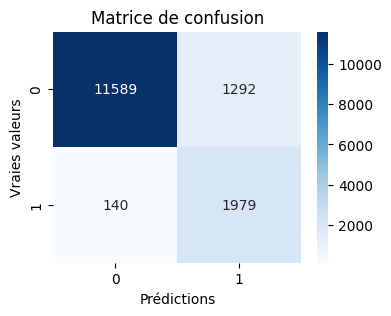

ROC-AUC: 0.9689965930921959


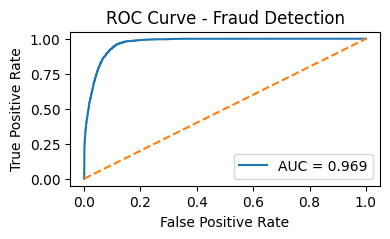

In [ ]:
#=======Charger les dataset propre=======================

df = pd.read_csv("../data/processed/dataset_propre.csv")

#============SEPARATION DE DATASET======================

X = df.drop('fraude', axis=1) # Variables
y = df["fraude"] # Target
print("Les variables d'entrées sont : ", X)
print("Les variables cibles : ", y)

#===============VERIFICATIONS DES VARIABLES CATEGORIELES================

X.dtypes

#======================ENCODAGE DE VARIABLES CATEGORIELS============

encoder = LabelEncoder()
colonnes_categorielles = [
    'pays',
    'appareil',
    'type_transaction',
    'categorie_commercant'
]
for col in colonnes_categorielles:
    X[col] = encoder.fit_transform(X[col])
X[col]
X.head()

#===================REPARTITION DE DONNEES ENTRAINNEMENT/EVALUATION DE MODELE=========================

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.3,
    random_state = 42 
)

#====================NORMALISATION DE DONNées=====================================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Appliquer sur le donnée d'entraiment 
X_test = scaler.fit_transform(X_test) # Appliquer sur le données de test

#===========VERIFICATION FINAL===========================================

print(X_train.shape)
print(X_test.shape)

#===================ENTRAINNEMENT DE MODELES=======================

model_lr = LogisticRegression(
    C=0.5,
    solver='liblinear',
    penalty='l2',
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

model_lr.fit(X_train,y_train)
y_pred_lr = model_lr.predict(X_test)
print(classification_report (y_test , y_pred_lr))


#+++++++++++++++++++++++++++++++++
model_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))


#+++++++++++++++++++++++++++++++++
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

#===============MATRICES DE CONFUSIONs===============

cm = confusion_matrix(y_test,y_pred_lr)

plt.figure(figsize=(4,3))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matrice de confusion")
plt.xlabel("Prédictions")
plt.ylabel("Vraies valeurs")

plt.show()

#=========================CALCULS DE PROBABILITES===================================

y_proba = model_lr.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(4,2))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve - Fraud Detection")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#================CROSS VALIDATION=====================

cv_scores = cross_val_score(
    model_lr,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("Scores CV:", cv_scores)
print("Moyenne:", cv_scores.mean())
print("Écart-type:", cv_scores.std())

#================VERIFICATION DE OVERFITING==============================

y_train_proba = model_lr.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_proba)

print("Train AUC:", train_auc)
print("Test AUC:", test_auc)